In [1]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
from src.battery import Battery
from src.optimize import run_simulation, get_daily_schedule
from src.load_data import load_data
from src.plot import display_schedule, display_profit, get_stats

import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)


# Battery specs :



- SOC: practical state of charge in [0,1] 
- NEC: practical nominal energy capacity (Wh)
- CR: Charging rate (W/Wh)
- DR: Discharging rate (W/Wh)





In [92]:
SOC = np.array([0, 0.01, 0.85, 1.0])

# Charging curve
CR = np.array([0.25, 0.9, 0.9, 0.1])

SOC_to_CR_function = interp1d(SOC, CR)

# Discharging curve
SOC = np.array([0.0, 0.15, 0.99, 1.0])
DR = np.array([0.1, 0.9, 0.9, 0.25])

SOC_to_DR_function = interp1d(SOC, DR)

bat = Battery(SOC_to_CR_function, SOC_to_DR_function, init_NEC=22080, init_eff=0.96, max_cycles=6000, price=6038, max_SOC=0.85, min_SOC=0.15)


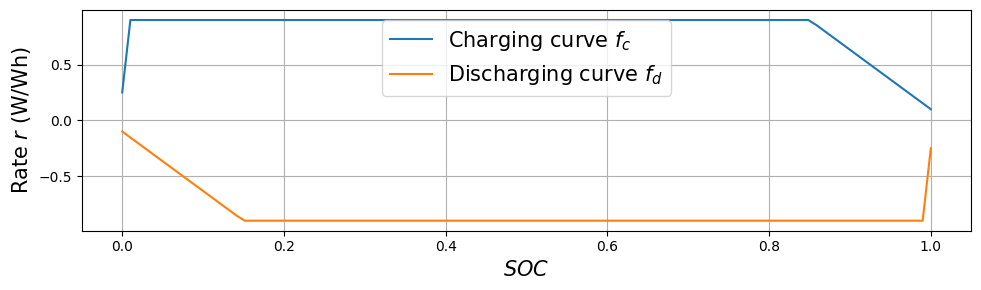

In [93]:
plt.figure(figsize=(10, 3))
plt.plot(
    np.linspace(0, 1, 100),
    SOC_to_CR_function(np.linspace(0, 1, 100)),
    label="Charging curve $f_c$",
)
plt.plot(
    np.linspace(0, 1, 100),
    -SOC_to_DR_function(np.linspace(0, 1, 100)),
    label="Discharging curve $f_d$",
)
plt.grid(True)
plt.xlabel("$SOC$", fontdict=dict(size=15))
plt.ylabel("Rate $r$ (W/Wh)", fontdict=dict(size=15))
plt.legend(loc="upper center", fontsize=15)
plt.tight_layout()
#plt.savefig("out/charging_curve.pdf")
plt.show()


# Dataset :

In [94]:
country = "France"


In [95]:
df = load_data(country=country, start="2021-01-01 00:00:00")
df


,Country,ISO3 Code,timestamp,Datetime (Local),price_euros_wh,vgc,fgc
1423427,France,FRA,2021-01-01 00:00:00,2021-01-01 01:00:00,4.819000e-05,0.000005,0
1423456,France,FRA,2021-01-01 01:00:00,2021-01-01 02:00:00,4.468000e-05,0.000005,0
1423485,France,FRA,2021-01-01 02:00:00,2021-01-01 03:00:00,4.292000e-05,0.000005,0
1423514,France,FRA,2021-01-01 03:00:00,2021-01-01 04:00:00,4.039000e-05,0.000005,0
1423543,France,FRA,2021-01-01 04:00:00,2021-01-01 05:00:00,4.020000e-05,0.000005,0
...,...,...,...,...,...,...,...
1931362,France,FRA,2022-12-31 19:00:00,2022-12-31 20:00:00,7.600000e-06,0.000005,0
1931391,France,FRA,2022-12-31 20:00:00,2022-12-31 21:00:00,3.690000e-06,0.000005,0
1931420,France,FRA,2022-12-31 21:00:00,2022-12-31 22:00:00,1.880000e-06,0.000005,0
1931449,France,FRA,2022-12-31 22:00:00,2022-12-31 23:00:00,1.000000e-07,0.000005,0


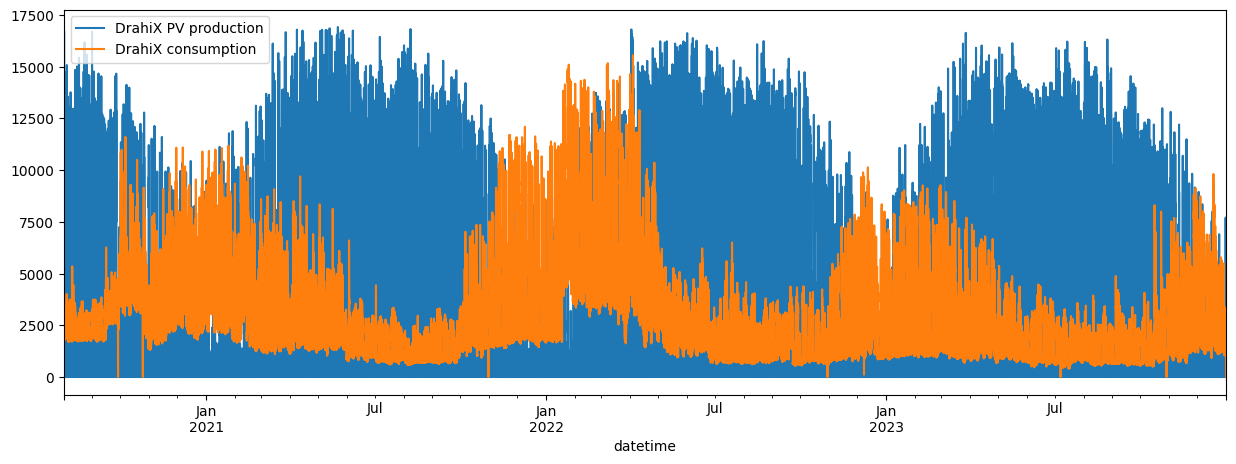

In [96]:
df_drahi = pd.read_csv("data/PV_DrahiX_modules_Meteo_SIRTA_conso_v4_20200801_20231231.csv", index_col=0, parse_dates=True)
consumption_columns = ['TGBT [kW]', 'kw_total_zone1', 'kw_total_zone2']
df_drahi['consumption'] = df_drahi.loc[:, consumption_columns].sum(axis=1) * 1000 / 10  # Convert kW to W

df_drahi['production'] = df_drahi['PAC']
df_drahi['production'] = df_drahi['production'].fillna(0)  # Fill NaN values with 0
df_drahi['production'].plot(figsize=(15, 5), label="DrahiX PV production")
df_drahi['consumption'].plot(figsize=(15, 5), label="DrahiX consumption")
plt.legend()

In [97]:
df_drahi_hourly = df_drahi.resample("h").mean()
df_drahi_hourly = df_drahi_hourly.loc["2021-01-01 01:00:00":"2023-01-01 00:00:00"]

df["pv_prod"] = df_drahi_hourly["production"].values
df["load_demand"] = df_drahi_hourly["consumption"].values
df

,Country,ISO3 Code,timestamp,Datetime (Local),price_euros_wh,vgc,fgc,pv_prod,load_demand
1423427,France,FRA,2021-01-01 00:00:00,2021-01-01 01:00:00,4.819000e-05,0.000005,0,0.0,6292.400
1423456,France,FRA,2021-01-01 01:00:00,2021-01-01 02:00:00,4.468000e-05,0.000005,0,0.0,7074.325
1423485,France,FRA,2021-01-01 02:00:00,2021-01-01 03:00:00,4.292000e-05,0.000005,0,0.0,7051.675
1423514,France,FRA,2021-01-01 03:00:00,2021-01-01 04:00:00,4.039000e-05,0.000005,0,0.0,7017.075
1423543,France,FRA,2021-01-01 04:00:00,2021-01-01 05:00:00,4.020000e-05,0.000005,0,0.0,7087.500
...,...,...,...,...,...,...,...,...,...
1931362,France,FRA,2022-12-31 19:00:00,2022-12-31 20:00:00,7.600000e-06,0.000005,0,0.0,1054.050
1931391,France,FRA,2022-12-31 20:00:00,2022-12-31 21:00:00,3.690000e-06,0.000005,0,0.0,1046.075
1931420,France,FRA,2022-12-31 21:00:00,2022-12-31 22:00:00,1.880000e-06,0.000005,0,0.0,1028.250
1931449,France,FRA,2022-12-31 22:00:00,2022-12-31 23:00:00,1.000000e-07,0.000005,0,0.0,1040.125


# true prices :

In [98]:
prices = [8.403e-05, 8.159e-05, 7.726e-05, 0.0001007, 0.00010069, 0.00012169, 0.00017529, 0.00018617, 0.00019805, 0.00019092, 0.00022007, 0.00021474, 0.0002316, 0.00023367, 0.00023708, 0.00023792, 0.00026, 0.0002556, 0.00022237, 0.00022274, 0.0001778, 0.00014898, 0.00012336, 0.00013025]
vgc = [0.0001] * 24
fgc = [0.0001] * 24
G_c, G_d = bat.max_SOC_change_charge, bat.min_SOC_change_discharge
pv_prod = [0, 0, 0, 0, 0, 0, 1000, 2000, 6000, 10000, 20000, 30000, 35000, 35000, 30000, 20000, 10000, 5000, 2000, 1000, 0, 0, 0, 0]
load_demand = [0, 0, 0, 0, 0, 0, 5000, 10000, 1000, 0, 0, 0, 0, 0, 0, 0, 2000, 2000, 5000, 10000, 5000, 2000, 0, 0]

daily_schedule = get_daily_schedule(prices, vgc, fgc, bat, G_c, G_d, add_pv_and_load=True, pv_prod=pv_prod, load_demand=load_demand, deg_cost=[0.0001])

Gurobi 13.0.0:Gurobi 13.0.0: optimal solution; objective 19.84851023
282 simplex iterations
1 branching node
absmipgap=3.55271e-15, relmipgap=0


In [99]:
daily_schedule

,pv_to_grid.val,pv_to_load.val,pv_to_bess.val,grid_to_load.val,grid_to_bess.val,bess_to_grid.val,bess_to_load.val,SOC.val
0,0,0,0,0,3450,0,0,0.150000
1,0,0,0,0,0,0,0,0.150000
2,0,0,0,0,12500,0,0,0.693478
3,0,0,0,0,0,0,0,0.693478
4,0,0,0,0,0,0,0,0.693478
5,0,0,0,0,0,0,0,0.693478
6,0,1000,0,0,0,0,4000,0.512319
7,0,2000,0,0,0,0,8000,0.150000
8,0,1000,5000,0,0,0,0,0.367391
9,0,0,10000,0,0,0,0,0.802174


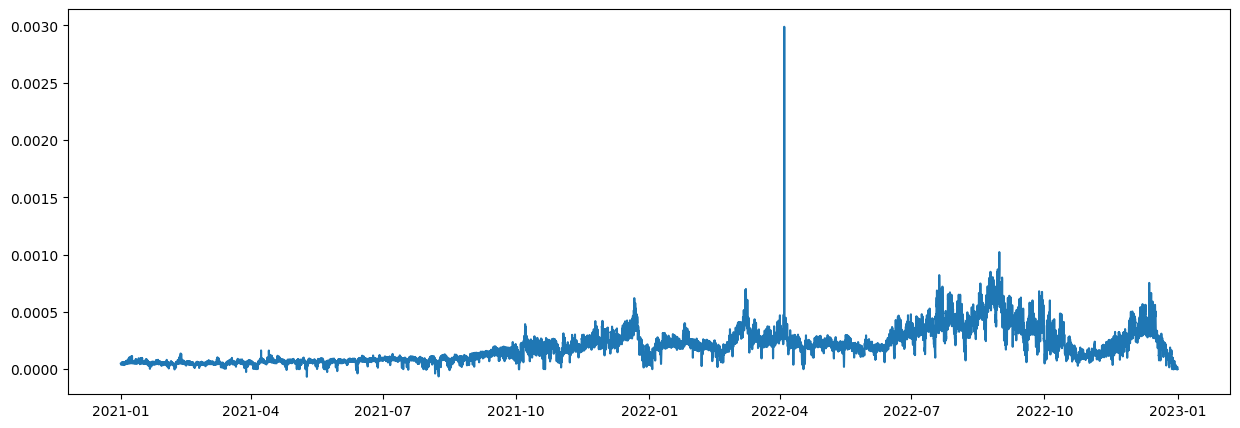

In [100]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.timestamp, df.price_euros_wh, label="Electricity price")

In [101]:
# df["pv_prod"] = np.tile(pv_prod, int(len(df) / len(pv_prod)))
# df["load_demand"] = np.tile(load_demand, int(len(df) / len(load_demand)))

In [ ]:
frame_size_forecast = 28
update_period = 1

df_optim = run_simulation(
    bat,
    start="2022-04-01 00:00:00",
    end="2022-05-15 00:00:00",
    df=df,
    forecasted=False,
    frame_size=frame_size_forecast,
    update_period=update_period,
    add_pv_and_load=True,
    time_horizon=48
)

# display_schedule(df_optim, name=country + "_optim_" + str(frame_size_forecast))
# display_profit(df_optim, name=country + "_optim_" + str(frame_size_forecast))


Gurobi 13.0.0:Gurobi 13.0.0: optimal solution; objective -153.2833371
1097 simplex iterations
1 branching node
absmipgap=0.00754194, relmipgap=4.92026e-05
Gurobi 13.0.0:Gurobi 13.0.0: optimal solution; objective -126.7261213
1143 simplex iterations
1 branching node
absmipgap=0.0124075, relmipgap=9.79083e-05
Gurobi 13.0.0:Gurobi 13.0.0: optimal solution; objective -144.2844879
1105 simplex iterations
1 branching node
absmipgap=2.84217e-14, relmipgap=0
Gurobi 13.0.0:Gurobi 13.0.0: optimal solution; objective -138.5556446
1382 simplex iterations
1 branching node
Gurobi 13.0.0:Gurobi 13.0.0: optimal solution; objective -132.6880763
1090 simplex iterations
1 branching node
Gurobi 13.0.0:Gurobi 13.0.0: optimal solution; objective -112.611058
1094 simplex iterations
1 branching node
absmipgap=0.00876097, relmipgap=7.77985e-05
Gurobi 13.0.0:Gurobi 13.0.0: optimal solution; objective -90.29728298
1125 simplex iterations
1 branching node
absmipgap=0.00848726, relmipgap=9.39924e-05
Gurobi 13.0.0:

In [108]:
df_optim[df_optim['timestamp'].dt.hour == 23].head(50)
df_optim.head(50)

,Country,ISO3 Code,timestamp,Datetime (Local),price_euros_wh,vgc,fgc,pv_prod,load_demand,n_cycles,...,price_forecast,pv_to_grid,pv_to_load,pv_to_bess,grid_to_load,grid_to_bess,bess_to_grid,bess_to_load,SOC,capacity
1740107,France,FRA,2022-04-01 00:00:00,2022-04-01 02:00:00,0.000257,0.000005,0,0.00000,4928.650,0.000000,...,0.000257,0.0,0.0,0.0,4928.65,0.0,0.0,0.0,0.15,3312.0
1740136,France,FRA,2022-04-01 01:00:00,2022-04-01 03:00:00,0.000250,0.000005,0,0.00000,5040.650,0.000000,...,0.000250,0.0,0.0,0.0,5040.65,0.0,0.0,0.0,0.15,3312.0
1740165,France,FRA,2022-04-01 02:00:00,2022-04-01 04:00:00,0.000249,0.000005,0,0.00000,5512.975,0.000000,...,0.000249,0.0,0.0,0.0,5512.975,16100.0,0.0,0.0,0.85,18768.0
1740194,France,FRA,2022-04-01 03:00:00,2022-04-01 05:00:00,0.000258,0.000005,0,0.00000,13274.000,0.000000,...,0.000258,0.0,0.0,0.0,13274.0,0.0,0.0,0.0,0.85,18768.0
1740223,France,FRA,2022-04-01 04:00:00,2022-04-01 06:00:00,0.000316,0.000005,0,0.00000,13995.625,0.000000,...,0.000316,0.0,0.0,0.0,13995.625,0.0,0.0,0.0,0.85,18768.0
1740252,France,FRA,2022-04-01 05:00:00,2022-04-01 07:00:00,0.000421,0.000005,0,440.08300,13533.825,0.000000,...,0.000421,0.0,440.083,0.0,13093.742,0.0,0.0,0.0,0.85,18768.0
1740281,France,FRA,2022-04-01 06:00:00,2022-04-01 08:00:00,0.000470,0.000005,0,887.08350,13270.850,0.000000,...,0.000470,887.0835,0.0,0.0,0.0,0.0,2185.15,13270.85,0.15,3312.0
1740310,France,FRA,2022-04-01 07:00:00,2022-04-01 09:00:00,0.000400,0.000005,0,1221.83325,12815.475,0.000000,...,0.000400,0.0,1221.83325,0.0,11593.64175,0.0,0.0,0.0,0.15,3312.0
1740339,France,FRA,2022-04-01 08:00:00,2022-04-01 10:00:00,0.000348,0.000005,0,647.66650,12911.775,0.000000,...,0.000348,0.0,647.6665,0.0,12264.1085,0.0,0.0,0.0,0.15,3312.0
1740368,France,FRA,2022-04-01 09:00:00,2022-04-01 11:00:00,0.000349,0.000005,0,1236.08325,12748.925,0.000000,...,0.000349,0.0,1236.08325,0.0,11512.84175,0.0,0.0,0.0,0.15,3312.0
